# Support Vector Machine (SVM)

To support the lecture 12 in Statistical Inference and Modeling 2102575 by *Suwichaya Suwanwimolkul, Ph.D.*

- [Data preprocessing](#data-preprocessing)
- [Training data distribution](#training-data-distribution)
- [Train SVM using different kernels: linear, poly, rbf](#training-the-svm-model-using-linear-poly-rbf)
- [Validating SVM using different kernels: linear, poly, rbf](#validating-performance-of-different-kernels)

## Data preprocessing

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import seaborn as sns

def train_validate_test_split(df, train_percent=.6, validate_percent=.2, seed=None):
    np.random.seed(seed)
    perm         = np.random.permutation(df.index)
    m            = len(df.index)
    train_end    = int(np.floor(int(train_percent * m)))
    validate_end = int(np.floor(int(validate_percent * m) + train_end))

    train        = df.iloc[perm[:train_end]]
    validate     = df.iloc[perm[train_end:validate_end]]
    test         = df.iloc[perm[validate_end:]]


    train       = train.reset_index(drop=True)
    validate    = validate.reset_index(drop=True)
    test        = test.reset_index(drop=True)

    return train, validate, test

In [3]:
foldername = "iris"
df_loaded = pd.read_csv("https://raw.githubusercontent.com/GenAI-CUEE/Statistical-Learning-EE575/refs/heads/master/Lab4/iris/iris_synthetic_data.csv")
df_loaded.keys()

label_string = np.unique(df_loaded['label'].values).tolist()
binary_label = [label_string[1], label_string[2]]


df_1 = df_loaded.loc[df_loaded['label'] == binary_label[0]]
df_2 = df_loaded.loc[df_loaded['label'] == binary_label[1]]

df   = pd.concat([df_1, df_2], ignore_index=True)

target_column = ['label']
feat_column   = ['sepal length', 'petal width'] # 'sepal length', 'sepal width', 'petal length', 'petal width'

all_column =  target_column + feat_column
df = df[all_column]
df = df.apply(LabelEncoder().fit_transform)

train_df,  valid_df, test_df = train_validate_test_split(df, train_percent=.8, validate_percent=.1, seed=None)

X_scaler = StandardScaler()
train_df[feat_column].values[:]        = X_scaler.fit_transform(train_df[feat_column].values[:] )
valid_df[feat_column].values[:]        = X_scaler.transform(valid_df[feat_column].values[:] )
test_df[feat_column].values[:]         = X_scaler.transform(test_df[feat_column].values[:] )


all_column = target_column + feat_column
train_enc = train_df[all_column]

print("# Training   dataset: %d" % len(train_df))
print("# Validating dataset: %d" % len(valid_df))
print("# Testing    dataset: %d" % len(test_df))

# Training   dataset: 1600
# Validating dataset: 200
# Testing    dataset: 200


## Training data distribution

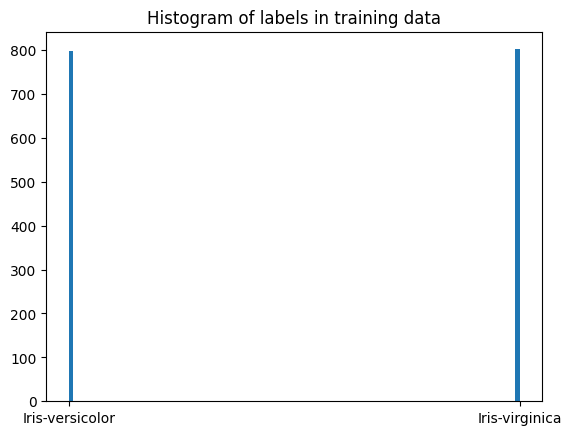

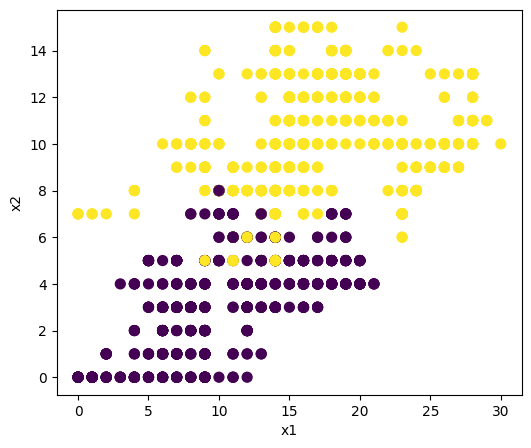

In [4]:
train_enc_array = train_enc[target_column].values

plt.hist(train_enc_array, bins=100)  # arguments are passed to np.histogram
plt.title("Histogram of labels in training data")
plt.xticks(np.unique(train_enc[target_column].values).tolist(), binary_label,  rotation=0)
plt.show()

x1 = train_enc[feat_column[0]].values
x2 = train_enc[feat_column[1]].values
y  = train_enc[target_column].values

plt.figure(figsize=(6, 5))
plt.scatter(x1, x2, c=y, s=50 )
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

## Training the SVM model using linear, poly, rbf

In [5]:
from sklearn import svm

X_train = train_enc[feat_column].values
y_train = train_enc[target_column].values

clf_linear = svm.SVC(kernel='linear')
clf_linear.fit(X_train, y_train)

clf_poly = svm.SVC(kernel='poly')
clf_poly.fit(X_train, y_train)

clf_rbf = svm.SVC(kernel='rbf')
clf_rbf.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC()

### Check how the model is shaped by the training data

In [6]:
def plotting_decision_contour(clf, X_train):
    h = 0.02  # step size in the mesh
    x1_min, x1_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
    x2_min, x2_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, h), np.arange(x2_min, x2_max, h))
    Z = clf.predict(np.c_[xx1.ravel(), xx2.ravel()])
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, cmap=plt.cm.Pastel2)


def show_trained_model_behavior(clf_list, clf_namelist, X_train, y_train):
    figsize=(15, 5)
    plt.figure(figsize=figsize)
    for index, (clf, name) in enumerate(zip(clf_list, clf_namelist)):
        plt.subplot(1, len(clf_list), index+1)

        plotting_decision_contour(clf, X_train)

        plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=50, alpha=0.95, edgecolors='k')
        plt.ylabel("x2")
        plt.xlabel("x1")
        plt.title("SVM with %s kernel" % name)

    plt.tight_layout()
    plt.savefig("trained_%s.png" % "-".join(clf_namelist))
    plt.show()


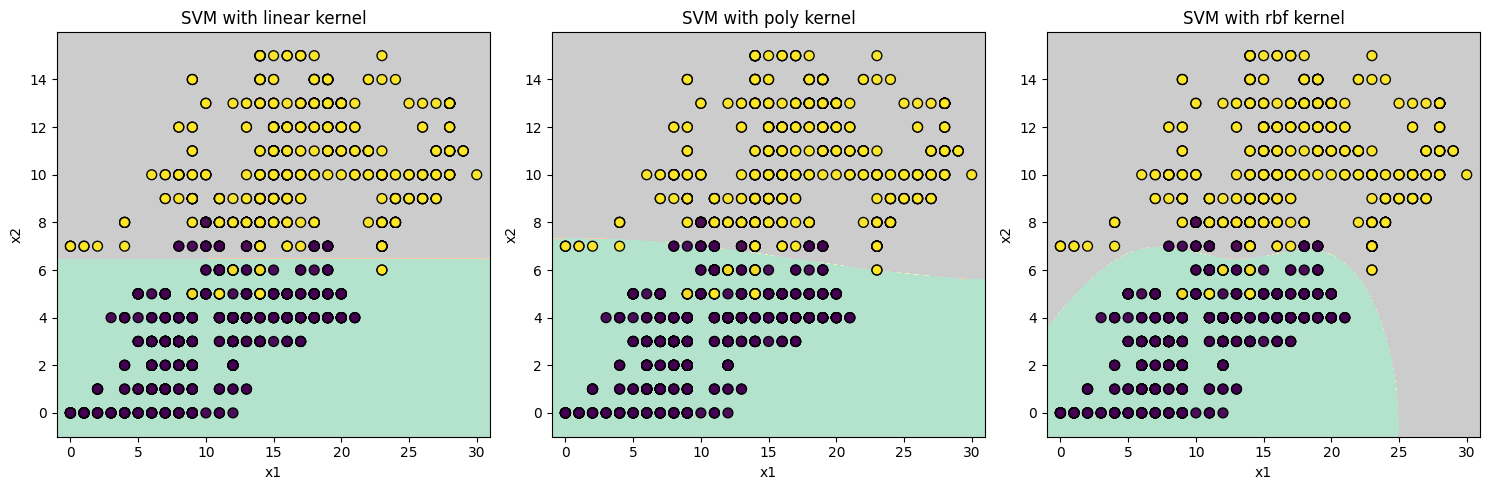

In [7]:
clf_list = [clf_linear, clf_poly, clf_rbf]
clf_name_list = ['linear', 'poly', 'rbf']
show_trained_model_behavior(clf_list, clf_name_list, X_train, y_train)


## Validating performance of different kernels

In the following, we use the learned model to predict the label by running

`y_pred = clf.predict(X_test) `

Then, we calculate the confusion matrix to evaluate the model performance.

`confusion_matrix(y_test, y_pred)`

Finally, we visualize the testing data samples compared to the decision boundary of the trained model.

In [8]:
from sklearn.metrics import confusion_matrix

X_valid = valid_df[feat_column].values
y_valid = valid_df[target_column].values.reshape(-1)


clf_list = [clf_linear, clf_poly, clf_rbf]
clf_name_list = ['linear', 'poly', 'rbf']

for clf, name in zip(clf_list, clf_name_list):
    y_pred = clf.predict(X_valid)
    print("Confusion Matrix for %s kernel:" % name)
    print(confusion_matrix(y_valid, y_pred))
    print()

Confusion Matrix for linear kernel:
[[108   2]
 [  1  89]]

Confusion Matrix for poly kernel:
[[109   1]
 [  1  89]]

Confusion Matrix for rbf kernel:
[[108   2]
 [  1  89]]



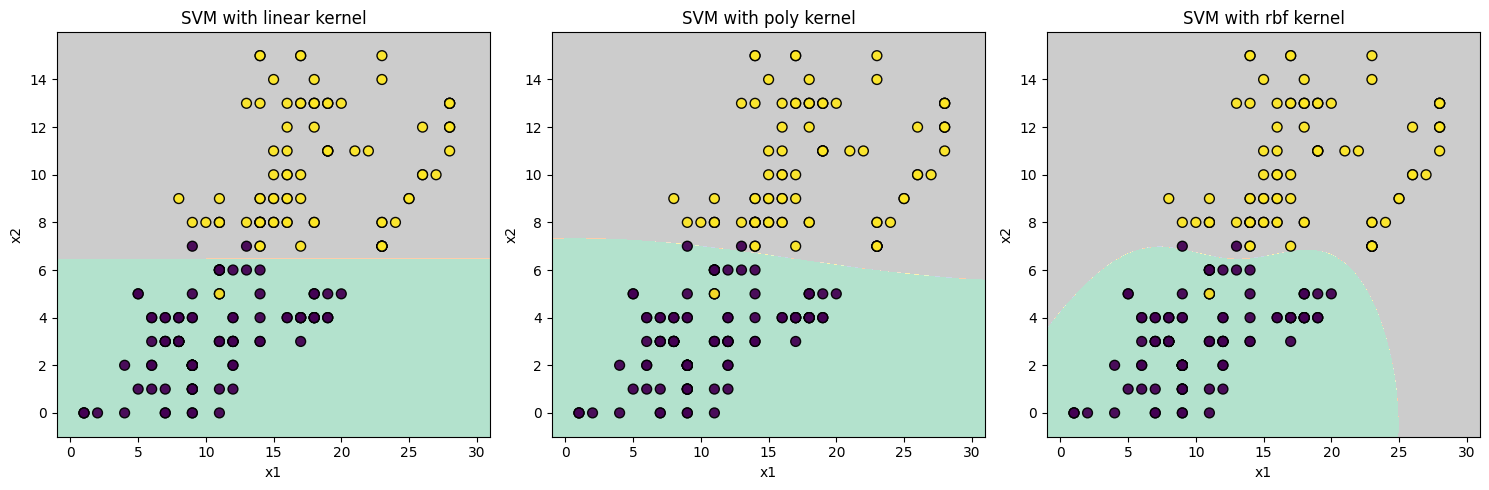

In [9]:
def show_valid_performance(clf_list, clf_namelist, X_test, y_test, X_train):
    figsize=(15, 5)
    plt.figure(figsize=figsize)
    for index, (clf, name) in enumerate(zip(clf_list, clf_namelist)):
        plt.subplot(1, len(clf_list), index+1)

        plotting_decision_contour(clf, X_train)

        plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, s=50, alpha=0.95, edgecolors='k')
        plt.ylabel("x2")
        plt.xlabel("x1")
        plt.title("SVM with %s kernel" % name)

    plt.tight_layout()
    plt.savefig("valid_%s.png" % "-".join(clf_namelist))
    plt.show()


show_valid_performance(clf_list, clf_name_list, X_valid, y_valid, X_train)

## Fine-tuning Phase

For find the optimal hyper-parameters

In [10]:
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define hyperparameter grid for the Poly kernel
C_values = [0.1, 1, 10, 100]
degree_values = [2, 3, 4, 5, 6, 8, 10]

best_acc = 0
best_C = None
best_degree = None

# Create a list to store all results
all_results = []

# 2. Loop through combinations
for C in C_values:
    for degree in degree_values:
        clf_tune = svm.SVC(kernel='poly', C=C, degree=degree)
        clf_tune.fit(X_train, y_train)

        y_valid_pred = clf_tune.predict(X_valid)
        acc = accuracy_score(y_valid, y_valid_pred)

        # Save the current combination's score
        all_results.append({'C': C, 'Degree': degree, 'Accuracy': acc})

        if acc > best_acc:
            best_acc = acc
            best_C = C
            best_degree = degree

# Convert results to a DataFrame for easy plotting
results_df = pd.DataFrame(all_results)

results_df.head()

results_df.to_csv('results.csv', index=False)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

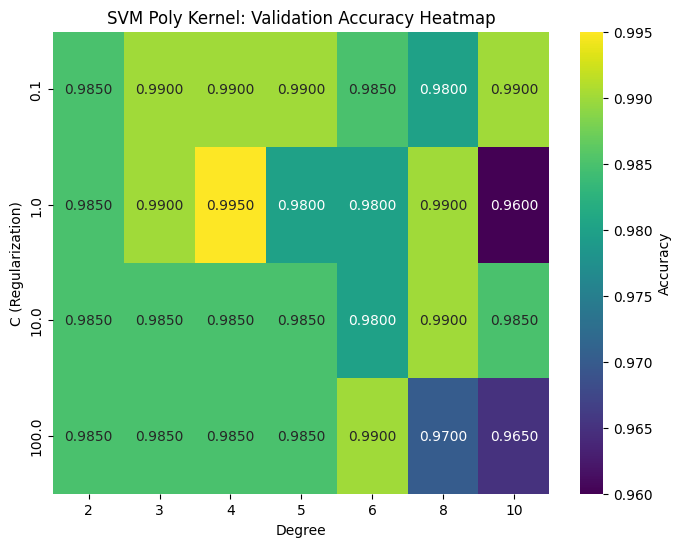

In [11]:
# Pivot the data so C is on the y-axis, Degree is on the x-axis
heatmap_data = results_df.pivot(index='C', columns='Degree', values='Accuracy')

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, cmap='viridis', fmt='.4f', cbar_kws={'label': 'Accuracy'})
plt.title('SVM Poly Kernel: Validation Accuracy Heatmap')
plt.xlabel('Degree')
plt.ylabel('C (Regularization)')
plt.show()

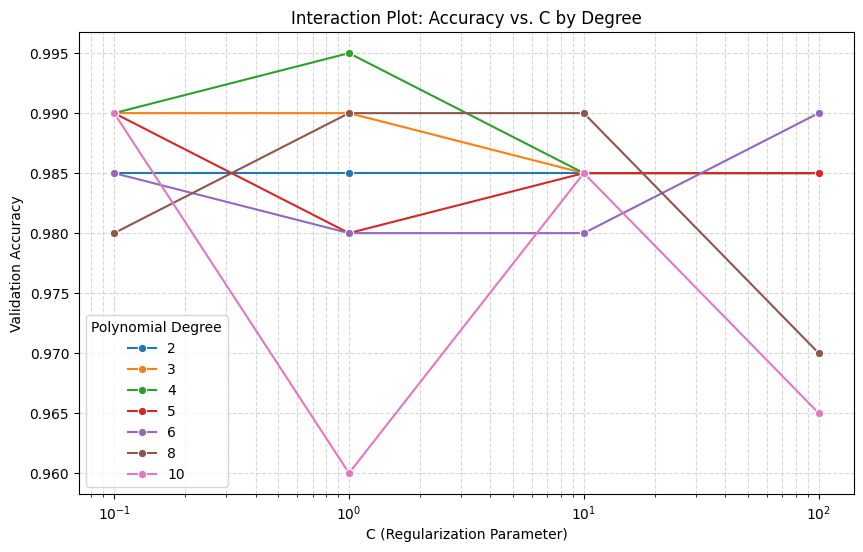

In [12]:
plt.figure(figsize=(10, 6))
# Create a line plot with C on x-axis and separate lines for each Degree
sns.lineplot(data=results_df, x='C', y='Accuracy', hue='Degree', marker='o', palette='tab10')

# Use a logarithmic scale for C since values are 0.1, 1, 10, 100
plt.xscale('log')

plt.title('Interaction Plot: Accuracy vs. C by Degree')
plt.xlabel('C (Regularization Parameter)')
plt.ylabel('Validation Accuracy')
plt.legend(title='Polynomial Degree')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()